# Binary Logistic Regression — Demo

This notebook follows this structure

1. **Dataset and Business Problem** — dataset, predictors, targets, business problem (binary only)
2. **EDA** — data understanding and exploration
3. **Data Preparation** — methodology, scaling, categoricals (binary only)
4. **Complete Model** — model with no adjustments
5. **Optimised Model** — features removed on the basis of EDA and correlations

> Scope note: this demo is **binary only**. Multiclass and regularisation are separate sessions
> with their own demos.



## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

---
## 1. Dataset and Business Problem
*Demo · mandatory · ~4 min*

**Business problem.** An airline wants to know **which passengers walk away satisfied** so it can
act on the factors that matter. We frame this as a **binary classification** task: predict whether
a passenger is *satisfied* versus *neutral or dissatisfied*.

**Target (binary).** `satisfaction` ∈ {satisfied, neutral or dissatisfied}.

**Predictors.** Three families:
- *Passenger / trip attributes* — Gender, Customer Type, Age, Type of Travel, Class, Flight Distance
- *Service ratings* (0–5 Likert) — wifi, online boarding, seat comfort, cleanliness, food, etc.
- *Operational* — departure and arrival delays (minutes)


In [2]:
df = pd.read_csv("airline.csv")

In [3]:
# Confirm the target is binary — this demo is binary only
print(df["satisfaction"].value_counts())
assert df["satisfaction"].nunique() == 2, "Target must be binary for this demo"
print("\nTarget is binary \u2713")

satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64

Target is binary ✓


---
## 2. Exploratory Data Analysis (EDA)

Before modeling, we must understand our target variable's balance and check for redundant features (multicollinearity) that could confuse our model's coefficients.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

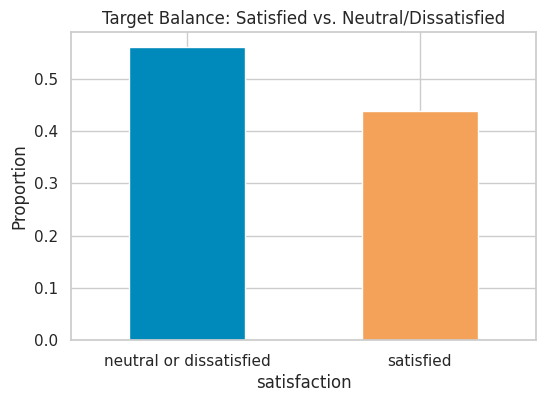

In [15]:
# Check Target Balance
plt.figure(figsize=(6, 4))
ax = df["satisfaction"].value_counts(normalize=True).plot(
    kind="bar", color=["#008ABC", "#F4A259"], rot=0)
ax.set_title("Target Balance: Satisfied vs. Neutral/Dissatisfied")
ax.set_ylabel("Proportion")
plt.show()

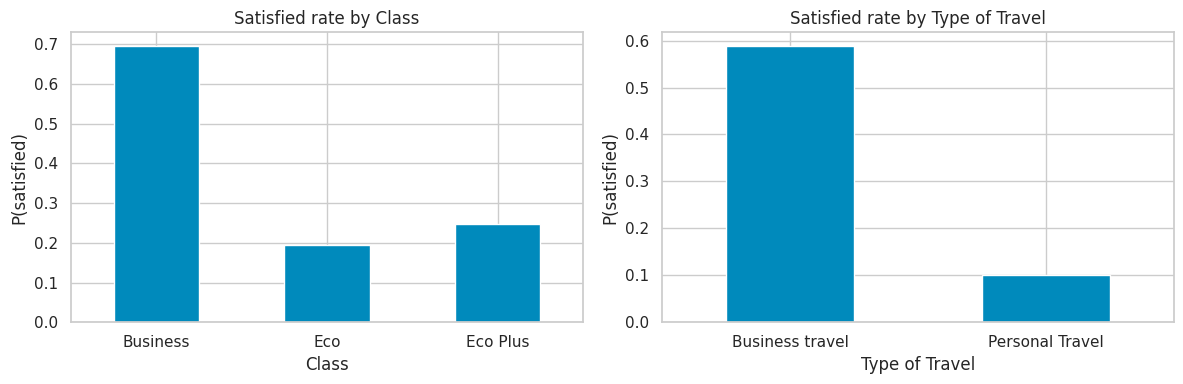

In [6]:
# Satisfaction rate across a couple of key categoricals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Class", "Type of Travel"]):
    (df.assign(sat=(df["satisfaction"] == "satisfied"))
       .groupby(col)["sat"].mean()
       .plot(kind="bar", ax=ax, color="#008ABC", rot=0))
    ax.set_title(f"Satisfied rate by {col}")
    ax.set_ylabel("P(satisfied)")
plt.tight_layout()
plt.show()

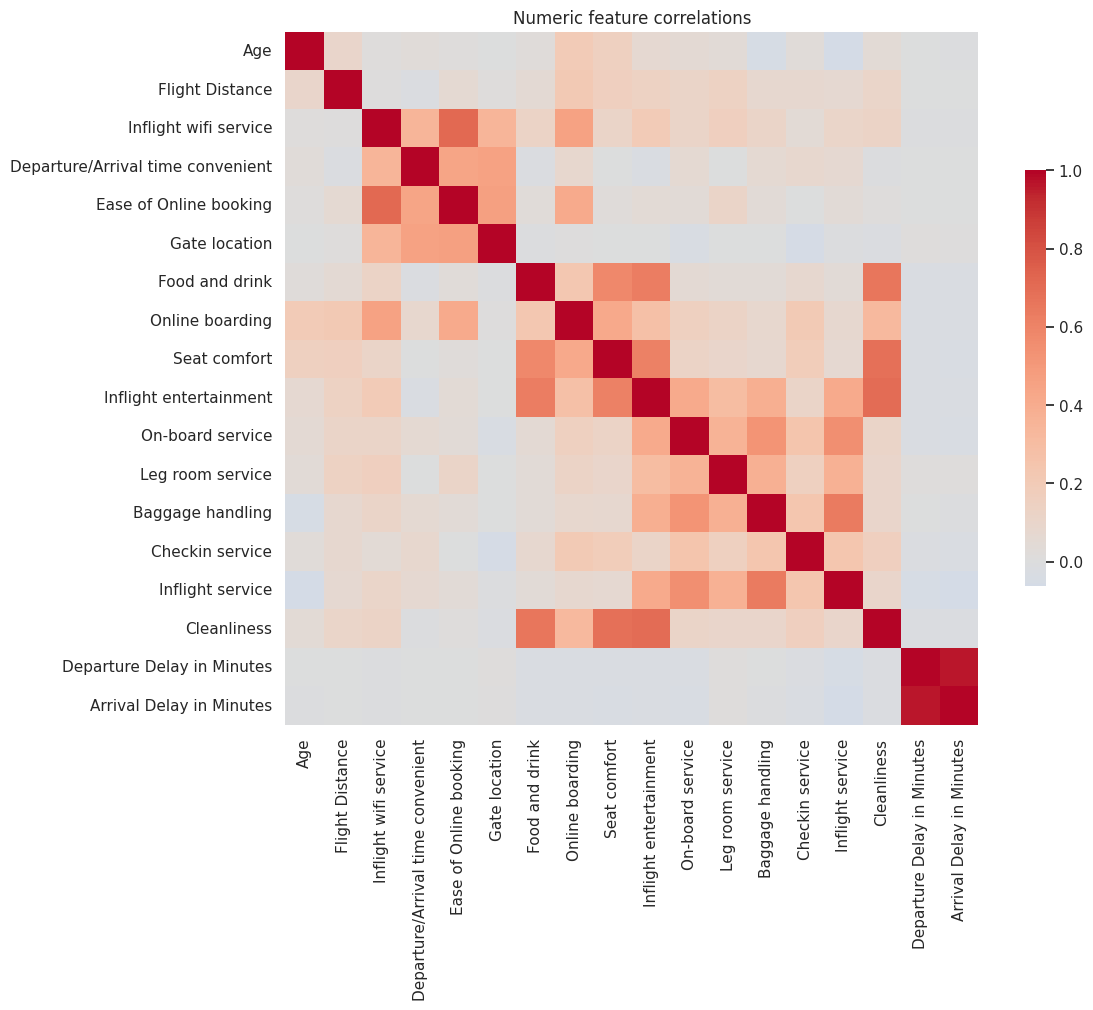

In [7]:
# Numeric correlation matrix — the basis for feature removal in the optimised model
numeric_all = df.select_dtypes(include=np.number).drop(columns=["Unnamed: 0", "id"],
                                                       errors="ignore")
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_all.corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6})
plt.title("Numeric feature correlations")
plt.show()


- **EDA Takeaways:**
1. Our target classes are relatively balanced.
2. `Departure Delay` and `Arrival Delay` are almost perfectly correlated. Carrying both into a model is redundant. We will act on this in our Optimised Model (Section 6).
- The service-rating columns form correlated clusters (e.g. wifi / online booking / entertainment).

These redundancies are what the optimised model will trim.

---
## 3. Data Preparation



Unlike Linear Regression where the target is a continuous number, Logistic Regression requires a binary numerical target (0 and 1). We will also manually encode our categories and scale our numerical features.

**Methodology:**
1. Drop non-predictive columns (`Unnamed: 0`, `id`).
2. Encode the **binary** target to 1/0.
3. Stratified 80/20 split (preserves class balance; reproducible).
4. Build the transform functions: **impute + scale** numerics, **one-hot encode** categoricals

In [17]:
# 1. Map the binary target explicitly
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# 2. Impute missing values manually (Arrival Delay has missing values)
median_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_delay)

# 3. Explicit One-Hot Encoding using Pandas
# Select categorical columns and create dummy variables, dropping the first level
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate predictors (X) and target (y)
X = df_encoded.drop('satisfaction', axis=1)
y = df_encoded['satisfaction']

# 4. Train-Test Split (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")

Train size: 20,780 | Test size: 5,196


In [18]:
# 5. Explicit Scaling
# We scale numerical features so large numbers (like Flight Distance) don't dominate the model.
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Fit on training data ONLY, then transform both to prevent data leakage
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
14748,-0.699109,-0.835410,-0.541340,0.621302,-0.537402,-0.765925,-0.914673,-0.926583,-1.095519,-1.015043,0.480940,-0.265567,0.311012,-0.245866,0.299646,-0.975429,-0.383067,-0.393678,True,False,True,True,False
4297,0.686271,-0.569498,0.959133,0.621302,1.585913,0.794766,-0.914673,1.282503,1.176501,0.481045,0.480940,0.493092,0.311012,-0.245866,0.299646,-0.216360,-0.142480,0.061641,False,False,False,False,False
14069,-0.237316,-1.091288,-1.291576,-0.031081,0.878141,0.014420,-0.162936,0.546141,-0.338179,-0.266999,-0.299592,-0.265567,-2.243132,-0.245866,-0.548094,0.542709,0.686207,0.436609,True,False,False,False,False
4849,-0.831050,-0.517319,0.208896,-0.031081,0.170369,-0.765925,1.340536,-0.190221,1.176501,1.229089,1.261473,1.251751,1.162394,-1.820317,-1.395834,1.301778,-0.195944,-0.393678,True,True,False,True,False
9303,1.543887,-0.462130,-1.291576,-1.335846,-1.245174,0.794766,1.340536,0.546141,-0.338179,-1.763088,-1.860657,-1.782885,-2.243132,0.541360,-2.243574,-1.734499,-0.089017,-0.179410,False,False,True,True,False


---
## 4. Complete Model and Interpretation
*Demo · mandatory · ~8 min*

The baseline: logistic regression on **every** feature, **no adjustments**. We fit, evaluate on the
held-out test set, and read the coefficients.

Logistic Regression models the **log-odds** of the positive class. The equation looks like this:

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1X_1 + \dots + \beta_nX_n$$

Because human brains struggle to interpret natural logarithms, we exponentiate the coefficients to calculate the **Odds Ratio** ($e^{\beta}$).

* **Odds Ratio > 1:** The feature *increases* the odds of being satisfied.
* **Odds Ratio < 1:** The feature *decreases* the odds of being satisfied.

*(Note: Because we used StandardScaler, a 1-unit increase in our numeric features actually represents a 1-standard-deviation increase).*

In [19]:
# Initialize and fit the complete model
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

# Extract features and calculate Odds Ratios
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Log_Odds_Coef': log_reg.coef_[0]
})

# Calculate Odds Ratio (exponentiate the log odds)
coef_df['Odds_Ratio'] = np.exp(coef_df['Log_Odds_Coef'])

# Sort by the most impactful drivers (highest absolute log-odds)
coef_df['Abs_Importance'] = coef_df['Log_Odds_Coef'].abs()
coef_df = coef_df.sort_values(by='Abs_Importance', ascending=False).drop(columns=['Abs_Importance'])

print(f"Intercept: {log_reg.intercept_[0]:.3f}\n")
coef_df.head(10)

Intercept: 1.027



,Feature,Log_Odds_Coef,Odds_Ratio
20,Type of Travel_Personal Travel,-2.761080,0.063223
19,Customer Type_disloyal Customer,-2.056069,0.127956
7,Online boarding,0.818981,2.268187
22,Class_Eco Plus,-0.686960,0.503103
21,Class_Eco,-0.634543,0.530178
2,Inflight wifi service,0.586233,1.797205
13,Checkin service,0.436501,1.547284
10,On-board service,0.372487,1.451340
11,Leg room service,0.318462,1.375011
15,Cleanliness,0.312539,1.366891


---
## 5. Model Evaluation: Continuous vs. Categorical

In the previous module (Linear Regression), we predicted a continuous number and evaluated performance using metrics measuring distance, like **RMSE** and **$R^2$**.

Because our target is now categorical, measuring "distance" no longer makes sense. Instead, we evaluate based on **correct classifications**. We organize our predictions into a **Confusion Matrix**:

1.  **True Positives (TP):** We predicted 'Satisfied', and they were 'Satisfied'.
2.  **True Negatives (TN):** We predicted 'Not Satisfied', and they were 'Not Satisfied'.
3.  **False Positives (FP):** We predicted 'Satisfied', but they were 'Not Satisfied'.
4.  **False Negatives (FN):** We predicted 'Not Satisfied', but they were 'Satisfied'.

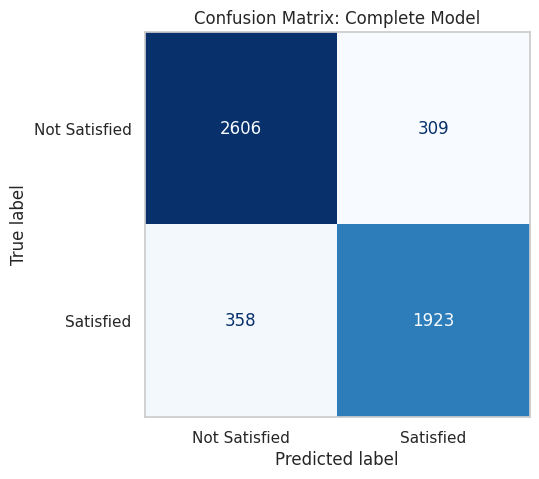

In [20]:
# Generate strict binary predictions
y_pred = log_reg.predict(X_test)

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Satisfied', 'Satisfied'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix: Complete Model")
plt.grid(False)
plt.show()

### Key Classification Metrics

From the four quadrants above, we derive business-critical metrics:

* **Accuracy:** Overall, how often is the model correct?
* **Precision:** When we predict a passenger is *Satisfied*, how often are we right? *(Crucial if giving perks to happy customers costs money—we want to avoid False Positives).*
* **Recall (Sensitivity):** Out of all truly *Satisfied* passengers, how many did we catch? *(Crucial if we want to ensure no happy customer is missed for a loyalty survey—we want to avoid False Negatives).*
* **F1-Score:** The harmonic mean balancing Precision and Recall.

### Evaluation metrics formula


| Metric | Formula | Reads as |
|---|---|---|
| **Accuracy** | (TP + TN) / all | overall fraction correct |
| **Precision** | TP / (TP + FP) | of those *predicted* satisfied, how many truly are |
| **Sensitivity** (recall) | TP / (TP + FN) | of the *truly* satisfied, how many we caught |

Two more **derived metric** the concept hints at:
- **F1** = harmonic mean of precision and sensitivity — one number when you care about both.
- **Specificity** or the true negative rate

In [23]:
def binary_metrics(y_true, y_pred):
    """Concept metrics derived from the confusion matrix (positive class = satisfied)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy":    (tp + tn) / (tp + tn + fp + fn),
        "precision":   tp / (tp + fp),
        "sensitivity": tp / (tp + fn),   # recall / true-positive rate
        "specificity": tn / (tn + fp),   # derived
        "f1":          2 * tp / (2 * tp + fp + fn),  # derived
    }

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TP={tp}   TN={tn}   FP={fp}   FN={fn}\n")
for name, val in binary_metrics(y_test, y_pred).items():
    print(f"{name:12s}: {val:.3f}")

TP=1923   TN=2606   FP=309   FN=358

accuracy    : 0.872
precision   : 0.862
sensitivity : 0.843
specificity : 0.894
f1          : 0.852


---
## 5. Optimised Model
---

In our EDA heatmap, we saw that `Departure Delay` and `Arrival Delay` were highly correlated. Providing both to the algorithm adds noise and destabilizes our coefficients.

**Rule:** For any numeric pair with an absolute correlation ($|r|$) above $0.7$, keep one and drop the other.

In [25]:
# Identify redundant features
THRESH = 0.7
corr = X_train[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > THRESH).any()]

print(f"Dropping {len(to_drop)} redundant feature(s) (|r| > {THRESH}): {to_drop}")

# Create reduced datasets
X_train_opt = X_train.drop(columns=to_drop)
X_test_opt = X_test.drop(columns=to_drop)

# Refit the model
log_reg_opt = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg_opt.fit(X_train_opt, y_train)

# Evaluate the Optimized Model
y_pred_opt = log_reg_opt.predict(X_test_opt)

print("\n--- OPTIMISED MODEL EVALUATION ---")
print("Accuracy on Test Data:", round(accuracy_score(y_test, y_pred_opt), 3))
print(classification_report(y_test, y_pred_opt, target_names=['Not Satisfied', 'Satisfied']))

Dropping 2 redundant feature(s) (|r| > 0.7): ['Ease of Online booking', 'Arrival Delay in Minutes']

--- OPTIMISED MODEL EVALUATION ---
Accuracy on Test Data: 0.87
               precision    recall  f1-score   support

Not Satisfied       0.88      0.89      0.89      2915
    Satisfied       0.86      0.84      0.85      2281

     accuracy                           0.87      5196
    macro avg       0.87      0.87      0.87      5196
 weighted avg       0.87      0.87      0.87      5196



In [26]:
from sklearn.metrics import precision_score, recall_score

# 1. Calculate metrics for the Complete Model
acc_comp = accuracy_score(y_test, y_pred)
prec_comp = precision_score(y_test, y_pred)
rec_comp = recall_score(y_test, y_pred)
features_comp = X_train.shape[1]

# 2. Calculate metrics for the Optimised Model
acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
features_opt = X_train_opt.shape[1]

# 3. Create a clean comparison dataframe
comparison = pd.DataFrame([
    {"Model": "Complete",
     "Features": features_comp,
     "Accuracy": acc_comp,
     "Precision": prec_comp,
     "Sensitivity (Recall)": rec_comp},
    {"Model": "Optimised",
     "Features": features_opt,
     "Accuracy": acc_opt,
     "Precision": prec_opt,
     "Sensitivity (Recall)": rec_opt}
])

# Round the numerical columns for readability
comparison = comparison.round(3)
comparison

,Model,Features,Accuracy,Precision,Sensitivity (Recall)
0,Complete,23,0.872,0.862,0.843
1,Optimised,21,0.870,0.859,0.843


**Takeaway.** The optimised model uses fewer predictors yet performs essentially the same — a
cleaner, more stable, more interpretable model for the same predictive power. That trade (drop
redundancy, keep performance) is the point of EDA/correlation-driven optimisation.

*Beyond feature removal, the next lever is **regularisation** — covered in the subsequent sessions*